# Model P- Random Forest - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate,StratifiedKFold, GridSearchCV
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

rfc =  RandomForestClassifier(random_state=RANDOM_STATE)

xtrain_P = pd.read_csv("../data/selected/xtrain_P.csv")
ytrain = pd.read_csv("../data/processed/ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=rfc,X=xtrain_P,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,9.691602,0.242394,0.723579,1.0
1,9.645083,0.215637,0.724691,1.0
2,9.283863,0.171144,0.712159,1.0
3,8.490642,0.160709,0.716487,1.0
4,8.876892,0.117001,0.705048,1.0


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.7163930026049756


Le Random Forest avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,716** en validation croisée, contre **1,000** sur l’entraînement.

L’écart entraînement–validation est donc d’environ **0,284**, ce qui met en évidence un surapprentissage important.

Cette baseline sert de référence pour vérifier si la régularisation du Random Forest permet de réduire cet écart tout en améliorant la généralisation.

## 3. Hyperparameter Tuning

In [3]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

settings_grid_2 = {
    "max_depth":[5, 10, 15, 20],
    "min_samples_leaf":[2, 5, 10],
    "min_samples_split":[2, 5, 10],
    "max_features":["sqrt", 0.5],
}


grid_search = GridSearchCV(estimator=rfc,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search_2 = GridSearchCV(estimator=rfc,param_grid=settings_grid_2,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_P,
    ytrain,
)



,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [4]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5}
Best validation F1: 0.723881083320845
Mean train F1: 0.8799550954622944
Std validation F1: 0.008519649283724033


Après optimisation, les meilleurs hyperparamètres sont `max_depth=20`, `max_features="sqrt"` et `min_samples_leaf=5`.

Le F1-macro moyen de validation atteint **0,724**, contre environ **0,716** pour la baseline. Le F1-macro moyen d’entraînement diminue à **0,880**.

L’écart entraînement–validation passe ainsi d’environ **0,284 à 0,156**. Le tuning réduit nettement le surapprentissage tout en améliorant légèrement la performance de validation.

L’écart-type du F1-macro de validation est d’environ **0,009**, ce qui indique une performance relativement stable entre les folds.

## 4. Final Evaluation

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_P = pd.read_csv("../data/selected/xtest_P.csv")
y_test = pd.read_csv("../data/processed/ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_P)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7501306847882906
Precision macro : 0.7207500992808878
Recall macro : 0.7115139469426922
F1 macro : 0.7130765828687432


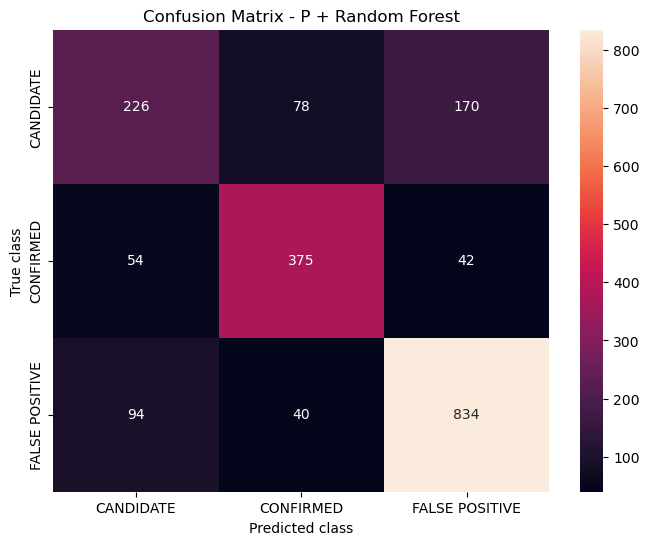

In [6]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - P + Random Forest")

plt.show()

Sur le jeu de test indépendant, le Random Forest optimisé avec la sélection personnelle obtient :

- **Accuracy : 0,7501**
- **Precision macro : 0,7208**
- **Recall macro : 0,7115**
- **F1 macro : 0,7131**

Le F1-macro de test est proche du score moyen obtenu en validation croisée (**0,7239**), ce qui indique une généralisation globalement cohérente.

Le tuning a surtout permis de réduire l’écart entre entraînement et validation, même si un surapprentissage reste présent.

## 5. Model Limits

La sélection personnelle permet au Random Forest d’obtenir de bonnes performances globales, mais la classe CANDIDATE reste nettement plus ambiguë que les deux autres. Cela suggère que les variables retenues manuellement capturent bien les signatures caractéristiques des objets confirmés et des faux positifs, mais qu’elles ne suffisent pas toujours à représenter les situations intermédiaires. Une limite possible de cette sélection est donc qu’elle repose sur des choix humains pertinents astrophysiquement, mais qui ne maximisent pas nécessairement la séparation statistique entre les trois classes.